In [1]:
import csv
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def bar_stick_sparam_plot_with_freq(freq, data_lists, labels,
                                    title="S-Parameter Comparison"):
    """
    freq        : frequency array (same for all variations)
    data_lists  : list of lists (each inner list = one variation)
    labels      : names of variations
    """

    freq = np.array(freq)

    mins, maxs, avgs = [], [], []
    fmins, fmaxs = [], []

    for data in data_lists:
        data = np.array(data)

        min_idx = np.argmin(data)
        max_idx = np.argmax(data)

        mins.append(data[min_idx])
        maxs.append(data[max_idx])
        avgs.append(np.mean(data))

        fmins.append(freq[min_idx] )  # convert to GHz
        fmaxs.append(freq[max_idx] )

    x = np.arange(len(labels))

    plt.figure(figsize=(11, 6))

    # Stick (min to max)
    for i in range(len(labels)):
        plt.plot([x[i], x[i]], [mins[i], maxs[i]], linewidth=3)

    # Average marker
    plt.scatter(x, avgs, s=100, zorder=3)

    # Min and max markers
    plt.scatter(x, mins, marker="_", s=250)
    plt.scatter(x, maxs, marker="_", s=250)

    # Annotate frequency at min/max
    for i in range(len(labels)):
        plt.text(x[i], mins[i],
                 f"{fmins[i]:.2f} GHz",
                 ha='center', va='top', fontsize=10, rotation=0)

        plt.text(x[i], maxs[i],
                 f"{fmaxs[i]:.2f} GHz",
                 ha='center', va='bottom', fontsize=10, rotation=0)

    plt.xticks(x, labels, rotation=45)
    plt.ylabel("S-Parameter (dB)")
    plt.title(title)
    plt.yticks(np.arange(min(mins),max(maxs), (max(maxs)-min(mins))/10)) # y-grid every 10 units
    plt.grid(True, axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [4]:
filename = 'Terminal S11 Parameter Plot1.csv'
fields = []  # Column names
rows = []    # Data rows
freqS11 = []
S11_14_5um = []
S11_16_5um = []
S11_17_5um = []
S11_18_5um = []
S11_19_5um = []
S11_20_5um = []
S11_21_5um = []
S11_22_5um = []
S11_23_5um = []
S11_25_5um = []
with open(filename, 'r') as csvfile:
    csvreader = csv.reader(csvfile)  # Reader object

    fields = next(csvreader)  # Read header
    for row in csvreader:     # Read rows
        rows.append(row)

In [5]:
fields

['Freq [GHz]',
 "dB(St(1,1)) [] - g='14.5um'",
 "dB(St(1,1)) [] - g='16.5um'",
 "dB(St(1,1)) [] - g='17.5um'",
 "dB(St(1,1)) [] - g='18.5um'",
 "dB(St(1,1)) [] - g='19.5um'",
 "dB(St(1,1)) [] - g='20.5um'",
 "dB(St(1,1)) [] - g='21.5um'",
 "dB(St(1,1)) [] - g='22.5um'",
 "dB(St(1,1)) [] - g='23.5um'",
 "dB(St(1,1)) [] - g='25.5um'"]

In [12]:
min_freq = 1 #ghz
max_freq = 45 #ghz
for r in rows:
    freqS11.append(float(r[0]))
    S11_14_5um.append(float(r[1]))
    S11_16_5um.append(float(r[2]))
    S11_17_5um.append(float(r[3]))
    S11_18_5um.append(float(r[4]))
    S11_19_5um.append(float(r[5]))
    S11_20_5um.append(float(r[6]))
    S11_21_5um.append(float(r[7]))
    S11_22_5um.append(float(r[8]))
    S11_23_5um.append(float(r[9]))
    S11_25_5um.append(float(r[10]))
    
min_freq_index = freqS11.index(min(filter(lambda f: f >= min_freq, freqS11)))
max_freq_index = freqS11.index(max(filter(lambda f: f <= max_freq, freqS11)))

In [13]:
max_freq_index

440

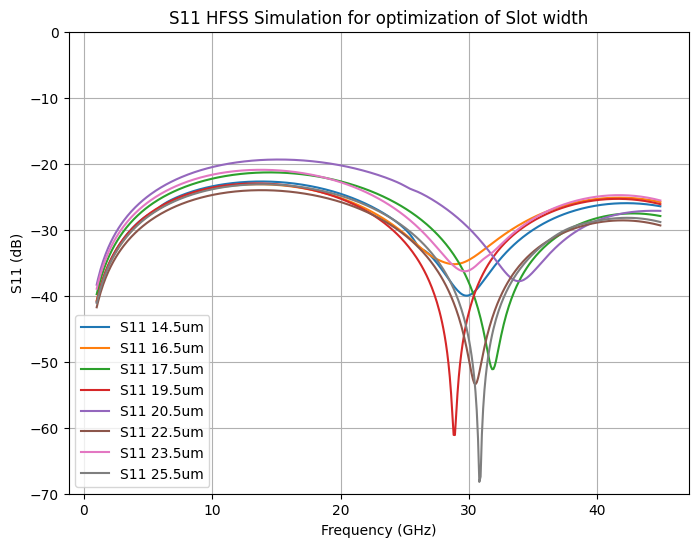

In [18]:
plt.figure(figsize=(8, 6))
plt.plot(freqS11[min_freq_index:max_freq_index], S11_14_5um[min_freq_index:max_freq_index], label="S11 14.5um")
plt.plot(freqS11[min_freq_index:max_freq_index], S11_16_5um[min_freq_index:max_freq_index], label="S11 16.5um")
plt.plot(freqS11[min_freq_index:max_freq_index], S11_17_5um[min_freq_index:max_freq_index], label="S11 17.5um")
plt.plot(freqS11[min_freq_index:max_freq_index], S11_19_5um[min_freq_index:max_freq_index], label="S11 19.5um")
plt.plot(freqS11[min_freq_index:max_freq_index], S11_20_5um[min_freq_index:max_freq_index], label="S11 20.5um")
plt.plot(freqS11[min_freq_index:max_freq_index], S11_22_5um[min_freq_index:max_freq_index], label="S11 22.5um")
plt.plot(freqS11[min_freq_index:max_freq_index], S11_23_5um[min_freq_index:max_freq_index], label="S11 23.5um")
plt.plot(freqS11[min_freq_index:max_freq_index], S11_25_5um[min_freq_index:max_freq_index], label="S11 25.5um")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S11 (dB)")
plt.title("S11 HFSS Simulation for optimization of Slot width")
plt.legend()
plt.ylim(-70, 0)  # Set y-axis limits for better visualization
plt.grid(True)
plt.show()

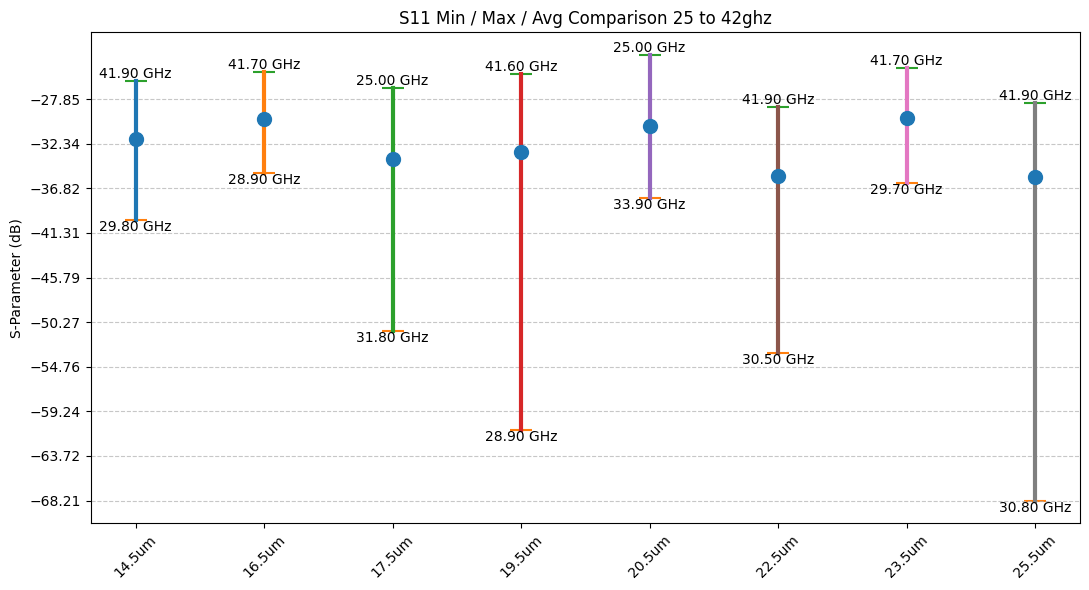

In [118]:
data = [
    S11_14_5um[min_freq_index:max_freq_index],
    S11_16_5um[min_freq_index:max_freq_index],
    S11_17_5um[min_freq_index:max_freq_index],
    S11_19_5um[min_freq_index:max_freq_index],
    S11_20_5um[min_freq_index:max_freq_index],
    S11_22_5um[min_freq_index:max_freq_index],
    S11_23_5um[min_freq_index:max_freq_index],
    S11_25_5um[min_freq_index:max_freq_index]
]

labels = [
    "14.5um", "16.5um", "17.5um", "19.5um",
    "20.5um", "22.5um", "23.5um", "25.5um"
]

bar_stick_sparam_plot_with_freq(freqS11[min_freq_index:max_freq_index], data, labels,title=f"S11 Min / Max / Avg Comparison {min_freq} to {max_freq}ghz")

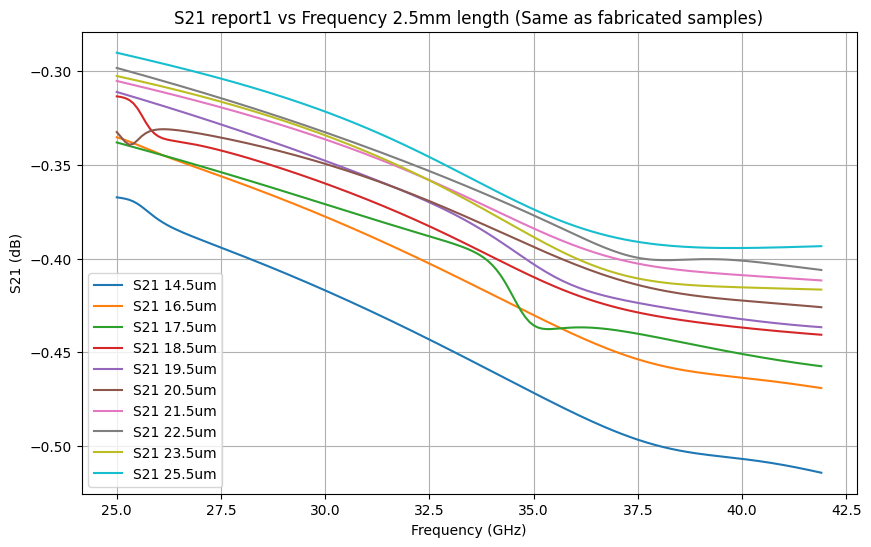

In [109]:
filename = 'Terminal S21 Parameter Plot2.csv'
fields = []  # Column names
rows = []    # Data rows
freqS21=[]
S21_14_5um = []
S21_16_5um = []
S21_17_5um = []
S21_18_5um = []
S21_19_5um = []
S21_20_5um = []
S21_21_5um = []
S21_22_5um = []
S21_23_5um = []
S21_25_5um = []
with open(filename, 'r') as csvfile:
    csvreader = csv.reader(csvfile)  # Reader object

    fields = next(csvreader)  # Read header
    for row in csvreader:     # Read rows
        rows.append(row)
for r in rows:
    freqS21.append(float(r[0]))
    S21_14_5um.append(float(r[1]))
    S21_16_5um.append(float(r[2]))
    S21_17_5um.append(float(r[3]))
    S21_18_5um.append(float(r[4]))
    S21_19_5um.append(float(r[5]))
    S21_20_5um.append(float(r[6]))
    S21_21_5um.append(float(r[7]))
    S21_22_5um.append(float(r[8]))
    S21_23_5um.append(float(r[9]))
    S21_25_5um.append(float(r[10]))

min_freq_index = freqS21.index(min(filter(lambda f: f >= min_freq, freqS21)))
max_freq_index = freqS21.index(max(filter(lambda f: f <= max_freq, freqS21)))

plt.figure(figsize=(10, 6))
plt.plot(freqS21[min_freq_index:max_freq_index], S21_14_5um[min_freq_index:max_freq_index], label="S21 14.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_16_5um[min_freq_index:max_freq_index], label="S21 16.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_17_5um[min_freq_index:max_freq_index], label="S21 17.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_18_5um[min_freq_index:max_freq_index], label="S21 18.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_19_5um[min_freq_index:max_freq_index], label="S21 19.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_20_5um[min_freq_index:max_freq_index], label="S21 20.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_21_5um[min_freq_index:max_freq_index], label="S21 21.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_22_5um[min_freq_index:max_freq_index], label="S21 22.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_23_5um[min_freq_index:max_freq_index], label="S21 23.5um")
plt.plot(freqS21[min_freq_index:max_freq_index], S21_25_5um[min_freq_index:max_freq_index], label="S21 25.5um")
plt.xlabel("Frequency (GHz)")
plt.ylabel("S21 (dB)")
plt.title("S21 report1 vs Frequency 2.5mm length (Same as fabricated samples)")
plt.legend()
plt.grid(True)
plt.show()

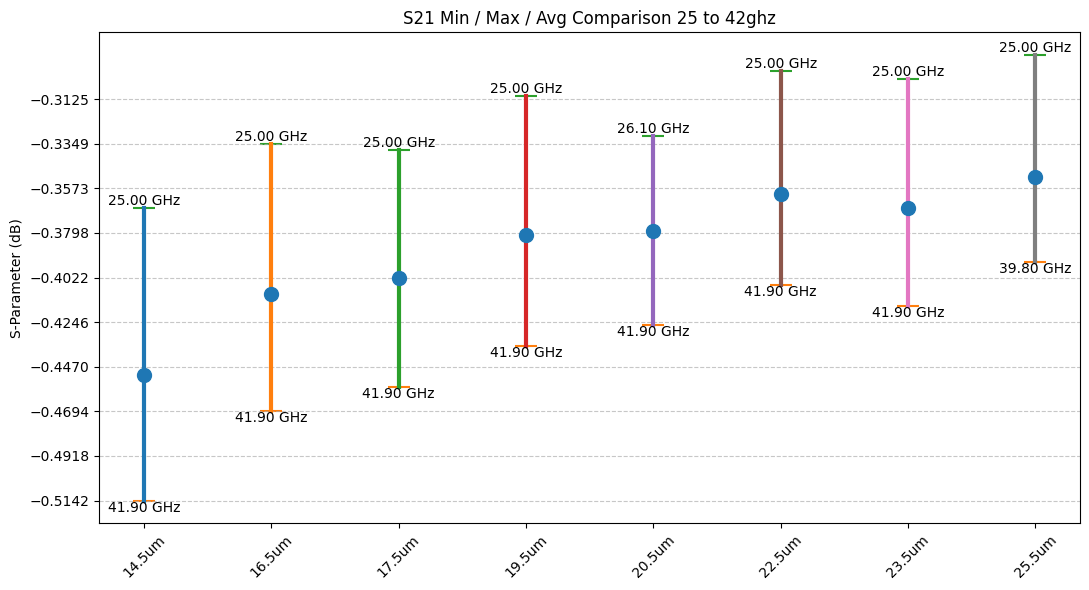

In [120]:
data = [
    S21_14_5um[min_freq_index:max_freq_index],
    S21_16_5um[min_freq_index:max_freq_index],
    S21_17_5um[min_freq_index:max_freq_index],
    S21_19_5um[min_freq_index:max_freq_index],
    S21_20_5um[min_freq_index:max_freq_index],
    S21_22_5um[min_freq_index:max_freq_index],
    S21_23_5um[min_freq_index:max_freq_index],
    S21_25_5um[min_freq_index:max_freq_index]
]

labels = [
    "14.5um", "16.5um", "17.5um", "19.5um",
    "20.5um", "22.5um", "23.5um", "25.5um"
]

bar_stick_sparam_plot_with_freq(freqS21[min_freq_index:max_freq_index], data, labels,title=f"S21 Min / Max / Avg Comparison {min_freq} to {max_freq}ghz")

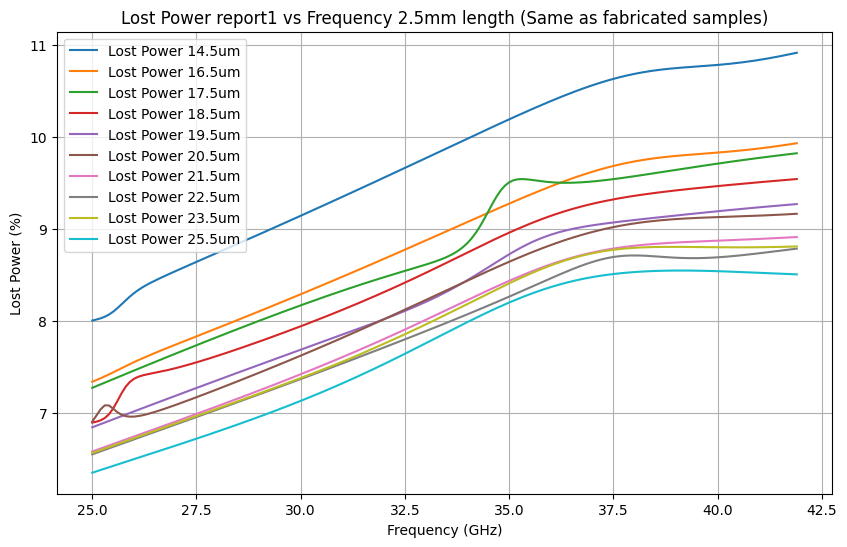

In [111]:
filename = 'lost_power_fraction.csv'
fields = []  # Column names
rows = []    # Data rows
freq_LPF = []
LostPower_14_5um = []
LostPower_16_5um = []
LostPower_17_5um = []
LostPower_18_5um = []
LostPower_19_5um = []
LostPower_20_5um = []
LostPower_21_5um = []
LostPower_22_5um = []
LostPower_23_5um = []
LostPower_25_5um = []

with open(filename, 'r') as csvfile:
    csvreader = csv.reader(csvfile)  # Reader object

    fields = next(csvreader)  # Read header
    for row in csvreader:     # Read rows
        rows.append(row)
for r in rows:
    freq_LPF.append(float(r[0]))
    LostPower_14_5um.append(100*float(r[1]))
    LostPower_16_5um.append(100*float(r[2]))
    LostPower_17_5um.append(100*float(r[3]))
    LostPower_18_5um.append(100*float(r[4]))
    LostPower_19_5um.append(100*float(r[5]))
    LostPower_20_5um.append(100*float(r[6]))
    LostPower_21_5um.append(100*float(r[7]))
    LostPower_22_5um.append(100*float(r[8]))
    LostPower_23_5um.append(100*float(r[9]))
    LostPower_25_5um.append(100*float(r[10]))

min_freq_index = freq_LPF.index(min(filter(lambda f: f >= min_freq, freq_LPF)))
max_freq_index = freq_LPF.index(max(filter(lambda f: f <= max_freq, freq_LPF)))

plt.figure(figsize=(10, 6))
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_14_5um[min_freq_index:max_freq_index], label="Lost Power 14.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_16_5um[min_freq_index:max_freq_index], label="Lost Power 16.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_17_5um[min_freq_index:max_freq_index], label="Lost Power 17.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_18_5um[min_freq_index:max_freq_index], label="Lost Power 18.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_19_5um[min_freq_index:max_freq_index], label="Lost Power 19.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_20_5um[min_freq_index:max_freq_index], label="Lost Power 20.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_21_5um[min_freq_index:max_freq_index], label="Lost Power 21.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_22_5um[min_freq_index:max_freq_index], label="Lost Power 22.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_23_5um[min_freq_index:max_freq_index], label="Lost Power 23.5um")
plt.plot(freq_LPF[min_freq_index:max_freq_index], LostPower_25_5um[min_freq_index:max_freq_index], label="Lost Power 25.5um")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Lost Power (%)")
plt.title("Lost Power report1 vs Frequency 2.5mm length (Same as fabricated samples)")
plt.legend()
plt.grid(True)
plt.show()

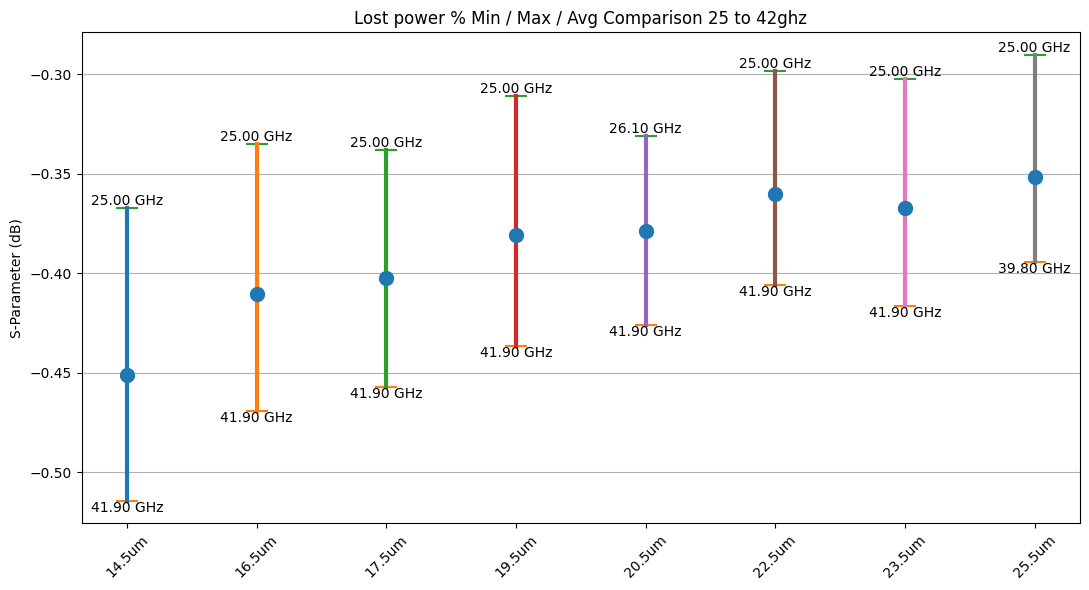

In [112]:
data = [
    S21_14_5um[min_freq_index:max_freq_index],
    S21_16_5um[min_freq_index:max_freq_index],
    S21_17_5um[min_freq_index:max_freq_index],
    S21_19_5um[min_freq_index:max_freq_index],
    S21_20_5um[min_freq_index:max_freq_index],
    S21_22_5um[min_freq_index:max_freq_index],
    S21_23_5um[min_freq_index:max_freq_index],
    S21_25_5um[min_freq_index:max_freq_index]
]

labels = [
    "14.5um", "16.5um", "17.5um", "19.5um",
    "20.5um", "22.5um", "23.5um", "25.5um"
]

bar_stick_sparam_plot_with_freq(freqS21[min_freq_index:max_freq_index], data, labels,title=f"Lost power % Min / Max / Avg Comparison {min_freq} to {max_freq}ghz")